# Notebook 9 – Classification Threshold Optimization

## Introduction to Classification Probability
Most classification models (like Logistic Regression, Random Forest, and XGBoost) do not directly predict a class. Instead, they calculate a **probability** (a value between 0 and 1) that a given sample belongs to the positive class.

### Default Threshold
By default, scikit-learn and most libraries use a **threshold of 0.5**. 
- If $P(class=1) \ge 0.5 \to$ Predicted Class = 1
- If $P(class=1) < 0.5 \to$ Predicted Class = 0

### Why Change the Threshold?
In many real-world scenarios, the cost of different types of errors is not equal:
- **False Positive (Type I Error):** Predicting "Positive" when it is actually "Negative". (e.g., an alarm going off when there is no fire).
- **False Negative (Type II Error):** Predicting "Negative" when it is actually "Positive". (e.g., missing a cancer diagnosis).

Depending on the business cost, you may want to move the threshold to prioritize either **Precision** or **Recall**.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score

# Create a dataset
np.random.seed(42)
X, y = make_classification(n_samples=1000, n_features=20, weights=[0.7, 0.3], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Get probabilities for the positive class
y_probs = model.predict_proba(X_test)[:, 1]

print("Model trained. Probabilities extracted.")

Model trained. Probabilities extracted.


## Threshold Tuning and Trade-offs
We will now experiment with different thresholds to see how they affect the model's performance.

In [12]:
thresholds = np.arange(0.1, 0.9, 0.1)
results = []

for t in thresholds:
    # Apply custom threshold
    y_pred_custom = (y_probs >= t).astype(int)
    
    results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_custom),
        'Recall': recall_score(y_test, y_pred_custom),
        'F1': f1_score(y_test, y_pred_custom),
        'Accuracy': accuracy_score(y_test, y_pred_custom)
    })

df_results = pd.DataFrame(results)
print(df_results)

   Threshold  Precision    Recall        F1  Accuracy
0        0.1   0.595745  0.933333  0.727273     0.790
1        0.2   0.739130  0.850000  0.790698     0.865
2        0.3   0.779661  0.766667  0.773109     0.865
3        0.4   0.788462  0.683333  0.732143     0.850
4        0.5   0.765957  0.600000  0.672897     0.825
5        0.6   0.785714  0.550000  0.647059     0.820
6        0.7   0.794872  0.516667  0.626263     0.815
7        0.8   0.812500  0.433333  0.565217     0.800


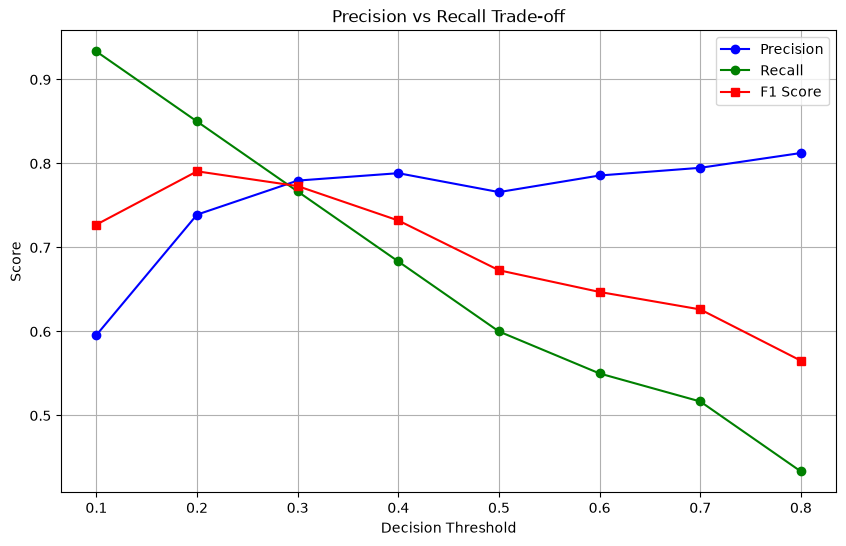

In [13]:
# Visualizing the Precision-Recall Trade-off
plt.figure(figsize=(10, 6))
plt.plot(df_results['Threshold'], df_results['Precision'], marker='o', label='Precision', color='blue')
plt.plot(df_results['Threshold'], df_results['Recall'], marker='o', label='Recall', color='green')
plt.plot(df_results['Threshold'], df_results['F1'], marker='s', label='F1 Score', color='red')
plt.title("Precision vs Recall Trade-off")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

## Analysis of the Results
- **Lowering the Threshold (e.g., 0.2):** Increases **Recall** (we catch more positives) but decreases **Precision** (we get more false positives). Useful for medical screening.
- **Raising the Threshold (e.g., 0.8):** Increases **Precision** (we are very sure when we say positive) but decreases **Recall** (we miss many positives). Useful for spam filters.
- **F1 Score:** The harmonic mean of precision and recall. It is useful when you want a balance between the two.